In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# enter your path name here
path_dir = os.path.expanduser('~/Documents/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv')

df = pd.read_csv(path_dir)
print(df.columns)
df.head(5)

df = df.drop(labels=['PatientID'], axis = 1)

Index(['PatientID', 'age', 'clinical.T.Stage', 'Clinical.N.Stage',
       'Clinical.M.Stage', 'Overall.Stage', 'Histology', 'gender',
       'Survival.time', 'deadstatus.event'],
      dtype='object')


In [3]:
def variable_selection(df, class_col):
    df_var = df
    df_var = df_var.drop(labels = class_col, axis = 1)
    cols = df_var.columns
    cat_var = []
    cont_var = []


    for col in cols:
        if len(df[col].unique()) <= 10:
            cat_var.append(col)
        else:
            cont_var.append(col)
        
    return cat_var, cont_var

In [4]:
cat_var, cont_var = variable_selection(df, 'Histology')
print(cat_var)
print(cont_var)

['clinical.T.Stage', 'Clinical.N.Stage', 'Clinical.M.Stage', 'Overall.Stage', 'gender', 'deadstatus.event']
['age', 'Survival.time']


In [15]:
def split_by_class(df, class_col):
    df_dict = {}
    outcome_classes = df[class_col].dropna().unique()
    
    for cls in outcome_classes:
        df_subset = df.loc[df[class_col] == cls]
        df_dict[cls] = df_subset

    return df_dict

In [16]:
df_dict = split_by_class(df,'Histology')

In [17]:
def calc_metrics(df, cat_var, cont_var):
    
    metrics_dict = {}
    
    for var in cat_var:
        # calculate % and absolute counts for each metric (count / total)
        subclasses = df[var].dropna().unique().tolist()
        subclasses.sort()

        var_metrics = []


        for cls in subclasses:
            
            #for each calsl, count how many have cls true, and take it over th etotal for that var

            count = df.loc[df[var] == cls][var].count()
            total = df[var].count()
            pc = (count / total) * 100

            var_metrics.append((('{}').format(cls), ('{}% ({} / {})').format(round(pc, 2), count, total)))

        metrics_dict[var] = var_metrics

 
    for var in cont_var:

        mean = df[var].mean()
        std = df[var].std()

        var_metrics = [(None, ('{} ± {}'.format(round(mean, 2), round(std, 2))))]

        metrics_dict[var] = var_metrics

    return metrics_dict  


In [24]:
metrics_dicts = {
    name: calc_metrics(df, cat_var, cont_var)
    for name, df in df_dict.items()
}

In [25]:
def metrics_to_multiindex_df(metrics_dict, column_name):
    rows = []
    for variable, entries in metrics_dict.items():
        for level, metric in entries:
            rows.append((variable, level, metric))
    
    df = pd.DataFrame(rows, columns=["variable", "level", column_name])
    return df.set_index(["variable", "level"])


In [26]:
metric_frames = {
    name: metrics_to_multiindex_df(mdict, column_name=name)
    for name, mdict in metrics_dicts.items()
}

combined = pd.concat(metric_frames.values(), axis=1)


In [29]:
combined = pd.concat(metric_frames.values(), axis=1)

In [ ]:
combined = combined.fillna('-')
combined

large cell squamous cell carcinoma  \
variable         level                                                
clinical.T.Stage 1.0      15.79% (18 / 114)       16.45% (25 / 152)   
                 2.0      41.23% (47 / 114)       36.18% (55 / 152)   
                 3.0       9.65% (11 / 114)       15.13% (23 / 152)   
                 4.0      32.46% (37 / 114)       32.24% (49 / 152)   
                 5.0        0.88% (1 / 114)                           
Clinical.N.Stage 0        28.07% (32 / 114)       41.45% (63 / 152)   
                 1          4.39% (5 / 114)        7.89% (12 / 152)   
                 2        42.11% (48 / 114)       32.89% (50 / 152)   
                 3        24.56% (28 / 114)       16.45% (25 / 152)   
                 4          0.88% (1 / 114)         1.32% (2 / 152)   
Clinical.M.Stage 0       98.25% (112 / 114)      100.0% (152 / 152)   
                 3          1.75% (2 / 114)                           
Overall.Stage    I        13.27% (15 / 113)       15.13% (23 / 152)   
                 II         4.42% (5 / 113)       15.13% (23 / 152)   
                 IIIa     31.86% (36 / 113)       28.95% (44 / 152)   
                 IIIb     50.44% (57 / 113)       40.79% (62 / 152)   
gender           female   37.72% (43 / 114)       26.32% (40 / 152)   
                 male     62.28% (71 / 114)      73.68% (112 / 152)   
deadstatus.event 0        13.16% (15 / 114)        8.55% (13 / 152)   
                 1        86.84% (99 / 114)      91.45% (139 / 152)   
age              NaN           66.9 ± 10.24             70.22 ± 9.9   
Survival.time    NaN      1098.41 ± 1107.24          848.9 ± 854.12   

                           adenocarcinoma                nos  
variable         level                                        
clinical.T.Stage 1.0     23.53% (12 / 51)   22.58% (14 / 62)  
                 2.0     43.14% (22 / 51)    37.1% (23 / 62)  
                 3.0      17.65% (9 / 51)     12.9% (8 / 62)  
                 4.0      15.69% (8 / 51)   27.42% (17 / 62)  
                 5.0                                          
Clinical.N.Stage 0       35.29% (18 / 51)   42.86% (27 / 63)  
                 1         7.84% (4 / 51)     1.59% (1 / 63)  
                 2       29.41% (15 / 51)   33.33% (21 / 63)  
                 3       27.45% (14 / 51)   22.22% (14 / 63)  
                 4                                            
Clinical.M.Stage 0       98.04% (50 / 51)   98.41% (62 / 63)  
                 3         1.96% (1 / 51)     1.59% (1 / 63)  
Overall.Stage    I       21.57% (11 / 51)   26.98% (17 / 63)  
                 II       15.69% (8 / 51)     3.17% (2 / 63)  
                 IIIa    27.45% (14 / 51)   23.81% (15 / 63)  
                 IIIb    35.29% (18 / 51)   46.03% (29 / 63)  
gender           female  37.25% (19 / 51)   28.57% (18 / 63)  
                 male    62.75% (32 / 51)   71.43% (45 / 63)  
deadstatus.event 0        11.76% (6 / 51)   15.87% (10 / 63)  
                 1       88.24% (45 / 51)   84.13% (53 / 63)  
age              NaN         67.27 ± 9.56      65.61 ± 10.22  
Survival.time    NaN     1067.16 ± 1165.7  1023.17 ± 1085.89

In [ ]:
classes = df['Histology'].dropna().unique()
table = pd.DataFrame(columns=['','Total'] + list(classes))
table

,,Total,large cell,squamous cell carcinoma,adenocarcinoma,nos


In [ ]:
### check if there is any missing value in the dataset ###
def check_missing(df, col):
    missing  = 0
    misVariables = []
    CheckNull = df.isnull().sum()
    for var in range(0, len(CheckNull)):
        misVariables.append([col[var], CheckNull[var], round(CheckNull[var]/len(df),3)*100])
        missing = missing + 1

    if missing == 0:
        print('Dataset is complete with no blanks.')
    else:
        df_misVariables = pd.DataFrame.from_records(misVariables)
        df_misVariables.columns = ['Variable', 'Missing', 'Percentage']
        s = df_misVariables.sort_values(by=['Percentage'], ascending=False).style.bar(subset=['Percentage'], color='#d65f5f')
        display(s)
    return df_misVariables
        
ranked_df_missing_value = check_missing(df, df.columns)

/var/folders/0v/0dzxw7vs5rxbc6p6k_4ss_r40000gn/T/ipykernel_3592/853342636.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  misVariables.append([col[var], CheckNull[var], round(CheckNull[var]/len(df),3)*100])


,Variable,Missing,Percentage
6,Histology,42,10.000000
1,age,22,5.200000
5,Overall.Stage,1,0.200000
2,clinical.T.Stage,1,0.200000
0,PatientID,0,0.000000
3,Clinical.N.Stage,0,0.000000
4,Clinical.M.Stage,0,0.000000
7,gender,0,0.000000
8,Survival.time,0,0.000000
9,deadstatus.event,0,0.000000


In [ ]:
df['Histology'].value_counts()
#df['Histology '].value_counts()

Histology
squamous cell carcinoma    152
large cell                 114
nos                         63
adenocarcinoma              51
Name: count, dtype: int64

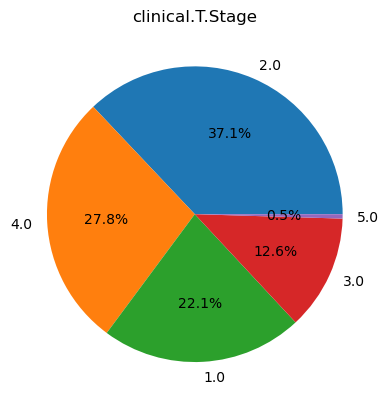

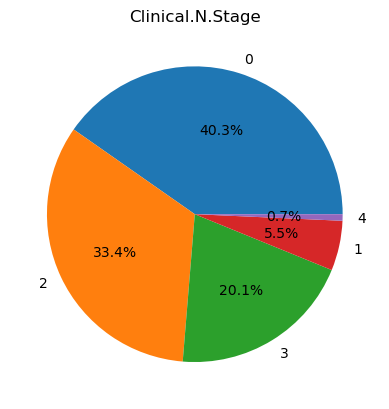

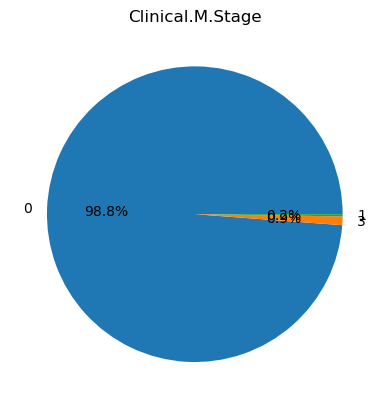

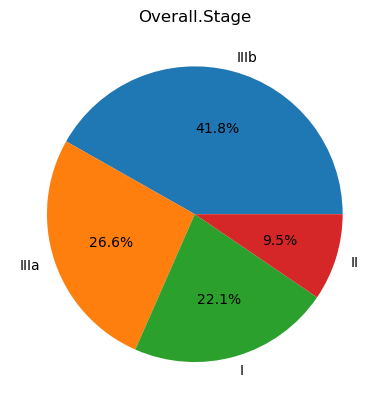

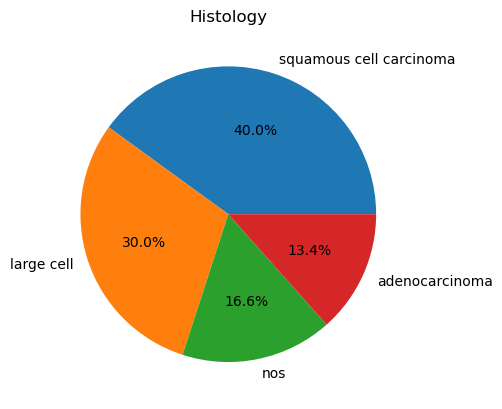

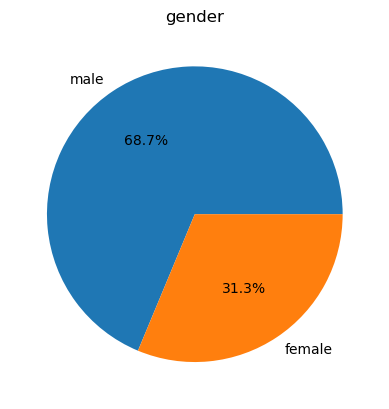

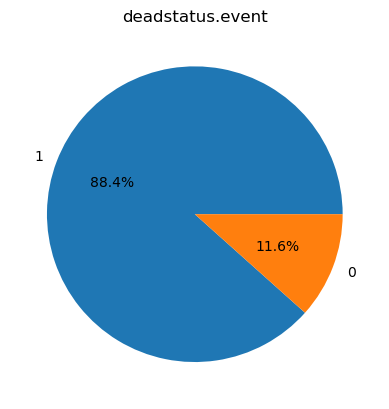

In [ ]:
for column in df[cat_var].columns:
    plt.pie(df[column].value_counts(), labels=df[column].value_counts().index, autopct='%1.1f%%')
    plt.title(column)
    plt.show()


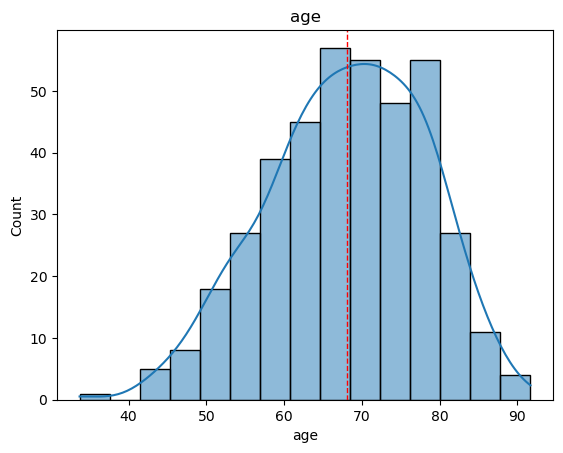

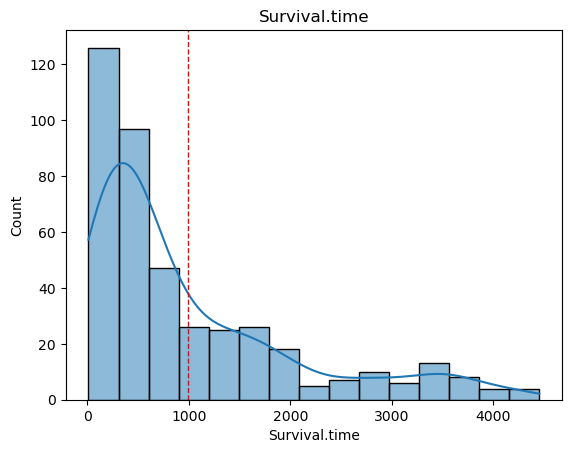

In [ ]:
for columns in df[cont_var].drop(labels='PatientID', axis=1).columns:
    sns.histplot(df[columns], kde=True)
    plt.axvline(df[columns].mean(), color='red', linestyle='dashed', linewidth=1)
    plt.title(columns)
    plt.show()